# **2. DAGs Propuestas por Expertos del Área Médica**

**Objetivo:** Traducir el conocimiento clínico sobre la fisiopatología de la Enfermedad Renal Crónica (ERC) a **grafos acíclicos dirigidos (DAGs)** sobre las variables del dataset, graficarlos y validarlos como estructuras candidatas para la Red Bayesiana Gaussiana.

---

Equipo MRI-art2-RBG

## **0. Por qué una DAG antes del modelo**

Una Red Bayesiana necesita **dos ingredientes**: la *estructura* (qué variable depende de cuál) y los *parámetros* (qué tan fuerte es cada dependencia). Los notebooks anteriores prepararon los datos para estimar los parámetros; este notebook define la **estructura**.

Existen dos caminos para obtener la estructura:

| Camino | Cómo se obtiene | Riesgo |
|---|---|---|
| **Aprendizaje estructural** | Un algoritmo la infiere de los datos (PC, Hill-Climbing, etc.) | Con 400 filas y correlaciones altas entre `hemo`–`pcv`–`rc`, el algoritmo puede orientar aristas al revés de lo que es fisiológicamente posible |
| **Elicitación de expertos** | Un clínico dicta el orden causal | Depende del experto, pero **garantiza que ninguna arista contradiga la fisiología** |

Este notebook toma el segundo camino. Las DAGs aquí propuestas servirán después como:

1. **Estructura fija** para ajustar la Red Bayesiana Gaussiana directamente.
2. **Restricciones** (aristas requeridas / prohibidas) para el aprendizaje estructural.
3. **Referencia** contra la cual comparar la estructura que el algoritmo aprenda solo.

### Convención de dirección

En todas las DAGs de este notebook una flecha `X → Y` se lee **"X ocurre antes y modifica a Y"**, nunca "X correlaciona con Y". Esto obliga a respetar tres reglas:

- **Temporalidad:** `age` no puede tener padres; nada causa la edad del paciente.
- **Enfermedad → signo:** el daño renal causa la alteración del laboratorio, no al revés. La creatinina sube *porque* el filtrado cayó.
- **Aciclicidad:** aunque la fisiología real tenga ciclos de retroalimentación, un DAG no los admite. Cuando aparezca uno, se documenta y se rompe explícitamente.

In [1]:
# --- Manejo de datos ---
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

# --- Grafos ---
import networkx as nx

# --- Visualización ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# --- Validación de la estructura como red bayesiana ---
from pgmpy.base import DAG

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## **1. Datos y Variables Disponibles**

Las DAGs solo pueden contener variables que existan en el dataset. Se localiza la raíz del proyecto y se cargan tanto el archivo crudo (25 variables, incluye el diagnóstico) como el imputado del notebook anterior (13 variables continuas).

In [2]:
# Localiza la raíz del proyecto subiendo hasta encontrar 'pyproject.toml'.
#   Así el notebook funciona sin importar si Jupyter se abrió en la raíz o dentro de 'notebook/'.
RAIZ = Path.cwd()
while not (RAIZ / 'pyproject.toml').exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent

print(f'Raíz del proyecto: {RAIZ}')

# Dataset crudo: contiene las 25 variables, incluido el diagnóstico 'classification'
crudo = pd.read_csv(RAIZ / 'data' / 'raw' / 'ckd.csv').drop(columns='id')

# Dataset imputado del notebook anterior: solo las 13 continuas que entran a la Red Gaussiana
ruta_imputado = RAIZ / 'notebook' / 'data' / 'processed' / 'ckd_imputado.csv'
imputado = pd.read_csv(ruta_imputado)

print(f'Crudo:    {crudo.shape[0]} filas x {crudo.shape[1]} variables')
print(f'Imputado: {imputado.shape[0]} filas x {imputado.shape[1]} variables')
print(f'\nVariables continuas disponibles para la Red Gaussiana:\n{list(imputado.columns)}')

Raíz del proyecto: /Users/juanpablo/Documents/R-studio/MRI-art_2-RBG
Crudo:    400 filas x 25 variables
Imputado: 400 filas x 13 variables

Variables continuas disponibles para la Red Gaussiana:
['age', 'bp', 'sg', 'al', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']


In [3]:
# Diccionario clínico: qué mide cada variable y qué papel juega en la fisiopatología renal.
#   La columna 'grupo' se usa después para colorear los nodos de las gráficas.
DICCIONARIO = {
    'age':            ('Edad',                        'Demográfico',    'Factor de riesgo no modificable; el filtrado glomerular cae ~1 mL/min por año tras los 40'),
    'bp':             ('Presión arterial',            'Hemodinámico',   'La hipertensión daña el glomérulo y es a la vez consecuencia de la retención de sodio'),
    'bgr':            ('Glucosa en sangre',           'Metabólico',     'La hiperglucemia sostenida produce nefropatía diabética, primera causa de ERC'),
    'sg':             ('Densidad urinaria',           'Función renal',  'Mide la capacidad de concentrar orina; cae cuando el túbulo se daña (isostenuria)'),
    'al':             ('Albúmina en orina',           'Función renal',  'Marca la ruptura de la barrera glomerular: la proteína pasa a la orina y baja en sangre'),
    'su':             ('Glucosa en orina',            'Metabólico',     'Aparece cuando la glucemia supera el umbral de reabsorción renal'),
    'bu':             ('Urea en sangre',              'Función renal',  'Producto nitrogenado que se acumula al perderse el filtrado'),
    'sc':             ('Creatinina sérica',           'Función renal',  'Mejor marcador indirecto del filtrado glomerular; sube cuando la depuración cae'),
    'sod':            ('Sodio sérico',                'Electrolitos',   'Se altera por la incapacidad renal de manejar agua y sal'),
    'pot':            ('Potasio sérico',              'Electrolitos',   'Se acumula en sangre al caer la excreción renal (hiperkalemia)'),
    'hemo':           ('Hemoglobina',                 'Hematológico',   'Baja por déficit de eritropoyetina, hormona que produce el riñón'),
    'pcv':            ('Hematocrito',                 'Hematológico',   'Volumen de glóbulos rojos; cae junto con la hemoglobina'),
    'rc':             ('Conteo de eritrocitos',       'Hematológico',   'Número de glóbulos rojos; misma causa que la anemia renal'),
    'wc':             ('Conteo de leucocitos',        'Inflamación',    'Sube por la inflamación crónica y las infecciones asociadas al daño renal'),
    'rbc':            ('Eritrocitos en orina',        'Urinario',       'Hematuria: sangre en orina por lesión glomerular'),
    'pc':             ('Células de pus en orina',     'Urinario',       'Leucocitos en orina, indicador de infección urinaria'),
    'pcc':            ('Cúmulos de células de pus',   'Urinario',       'Agregados de leucocitos, infección más establecida'),
    'ba':             ('Bacterias en orina',          'Urinario',       'Causa directa de la infección del tracto urinario'),
    'htn':            ('Hipertensión (dx)',           'Comorbilidad',   'Diagnóstico previo de hipertensión arterial crónica'),
    'dm':             ('Diabetes mellitus (dx)',      'Comorbilidad',   'Diagnóstico previo de diabetes'),
    'cad':            ('Enfermedad coronaria',        'Comorbilidad',   'Comparte factores de riesgo con la ERC (edad, HTA, diabetes)'),
    'appet':          ('Apetito',                     'Síntoma',        'La anorexia es un síntoma del síndrome urémico'),
    'pe':             ('Edema en pies',               'Síntoma',        'Retención de líquido por pérdida de albúmina y de sodio'),
    'ane':            ('Anemia (dx)',                 'Hematológico',   'Etiqueta clínica derivada de la hemoglobina baja'),
    'classification': ('Diagnóstico de ERC',          'Diagnóstico',    'Variable objetivo: ckd / notckd'),
}

diccionario = pd.DataFrame(
    [(k, v[0], v[1], v[2]) for k, v in DICCIONARIO.items()],
    columns=['variable', 'significado', 'grupo', 'papel en la fisiopatología de la ERC']
).set_index('variable')

diccionario

,significado,grupo,papel en la fisiopatología de la ERC
variable,,,
age,Edad,Demográfico,Factor de riesgo no modificable; el filtrado g...
bp,Presión arterial,Hemodinámico,La hipertensión daña el glomérulo y es a la ve...
bgr,Glucosa en sangre,Metabólico,La hiperglucemia sostenida produce nefropatía ...
sg,Densidad urinaria,Función renal,Mide la capacidad de concentrar orina; cae cua...
al,Albúmina en orina,Función renal,Marca la ruptura de la barrera glomerular: la ...
su,Glucosa en orina,Metabólico,Aparece cuando la glucemia supera el umbral de...
bu,Urea en sangre,Función renal,Producto nitrogenado que se acumula al perders...
sc,Creatinina sérica,Función renal,Mejor marcador indirecto del filtrado glomerul...
sod,Sodio sérico,Electrolitos,Se altera por la incapacidad renal de manejar ...


## **2. Herramientas de Construcción y Graficado**

Antes de declarar las estructuras se definen tres utilidades que se reutilizan en todas las propuestas:

- `construir_dag`: arma el grafo y **verifica que sea acíclico**; si el experto dictó un ciclo, aquí se detecta.
- `posiciones_por_capas`: coloca cada nodo en la capa que le corresponde según su distancia causal al origen, de izquierda a derecha. Una DAG dibujada al azar es ilegible; dibujada por capas se lee como la cascada fisiopatológica que representa.
- `graficar_dag`: dibuja el grafo coloreando cada nodo por su grupo clínico. En las figuras el nodo `class` corresponde a `classification`, abreviado para que quepa la etiqueta.

In [4]:
# Paleta por grupo clínico. Se mantiene igual en todas las gráficas para poder compararlas.
# 'classification' no cabe dentro del nodo; se dibuja abreviada.
ETIQUETAS = {'classification': 'class'}

COLORES = {
    'Demográfico':   '#b0bec5',
    'Comorbilidad':  '#ce93d8',
    'Metabólico':    '#ffcc80',
    'Hemodinámico':  '#ef9a9a',
    'Función renal': '#90caf9',
    'Electrolitos':  '#80cbc4',
    'Hematológico':  '#f48fb1',
    'Inflamación':   '#fff59d',
    'Urinario':      '#c5e1a5',
    'Síntoma':       '#bcaaa4',
    'Diagnóstico':   '#455a64',
}


def construir_dag(aristas, nodos_extra=(), nombre='DAG'):
    '''Arma un DiGraph y valida que sea acíclico. Si hay ciclo, lo reporta y falla.'''
    G = nx.DiGraph()
    G.add_nodes_from(nodos_extra)
    G.add_edges_from(aristas)

    if not nx.is_directed_acyclic_graph(G):
        ciclos = list(nx.simple_cycles(G))
        raise ValueError(f'{nombre} NO es acíclica. Ciclos encontrados: {ciclos}')

    print(f'{nombre}: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas — acíclica ✔')
    return G


def capas_topologicas(G):
    '''Capa de cada nodo = longitud del camino más largo desde cualquier raíz.'''
    capa = {}
    for n in nx.topological_sort(G):
        padres = list(G.predecessors(n))
        capa[n] = 0 if not padres else max(capa[p] for p in padres) + 1
    return capa


def posiciones_por_capas(G, sep_x=1.0, sep_y=1.0, pasadas=8):
    '''Layout por capas con reordenamiento baricéntrico para reducir cruces de aristas.'''
    capa = capas_topologicas(G)
    orden = defaultdict(list)
    for n, c in sorted(capa.items()):
        orden[c].append(n)

    y = {n: i for c in orden for i, n in enumerate(orden[c])}

    def reordenar(capas_iter, vecinos):
        for c in capas_iter:
            orden[c].sort(key=lambda n: np.mean([y[v] for v in vecinos(n)]) if list(vecinos(n)) else y[n])
            for i, n in enumerate(orden[c]):
                y[n] = i

    capas = sorted(orden)
    for _ in range(pasadas):
        reordenar(capas[1:], G.predecessors)     # baja: alinea con los padres
        reordenar(capas[:-1][::-1], G.successors)  # sube: alinea con los hijos

    ancho_max = max(len(ns) for ns in orden.values())
    pos = {}
    for c, ns in orden.items():
        desfase = (ancho_max - len(ns)) / 2
        for i, n in enumerate(ns):
            pos[n] = (c * sep_x, -(i + desfase) * sep_y)
    return pos


def graficar_dag(G, titulo, figsize=(14, 8), tam_nodo=1700, fuente=9,
                 aristas_extra=None, sep_x=1.0, sep_y=1.0, leyenda=True,
                 ax=None, colores_aristas=None):
    '''Dibuja la DAG por capas.

    aristas_extra    : se pintan punteadas en rojo (retroalimentación omitida).
    colores_aristas  : dict {(origen, destino): color} para resaltar subconjuntos
                       de aristas; las no listadas usan el gris por defecto.
    '''
    pos = posiciones_por_capas(G, sep_x=sep_x, sep_y=sep_y)
    grupos = [DICCIONARIO.get(n, ('', 'Demográfico', ''))[1] for n in G.nodes()]
    colores = [COLORES[g] for g in grupos]
    texto = ['white' if g == 'Diagnóstico' else 'black' for g in grupos]

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    por_color = defaultdict(list)
    for e in G.edges():
        por_color[(colores_aristas or {}).get(e, '#546e7a')].append(e)

    for color, aristas in por_color.items():
        nx.draw_networkx_edges(G, pos, edgelist=aristas, ax=ax, edge_color=color,
                               width=2.2 if color != '#546e7a' else 1.4,
                               arrowsize=14, arrowstyle='-|>',
                               node_size=tam_nodo, min_source_margin=6, min_target_margin=10)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colores, node_size=tam_nodo,
                           edgecolors='#37474f', linewidths=1.2)

    for n, c in zip(G.nodes(), texto):
        ax.text(*pos[n], ETIQUETAS.get(n, n), ha='center', va='center',
                fontsize=fuente, fontweight='bold', color=c)

    if aristas_extra:
        nx.draw_networkx_edges(G, pos, edgelist=aristas_extra, ax=ax,
                               edge_color='#c62828', width=1.8, style='dashed',
                               arrowsize=14, arrowstyle='-|>', connectionstyle='arc3,rad=-0.35',
                               node_size=tam_nodo, min_source_margin=6, min_target_margin=10)

    if leyenda:
        presentes = sorted(set(grupos), key=list(COLORES).index)
        ax.legend(handles=[mpatches.Patch(facecolor=COLORES[g], edgecolor='#37474f', label=g)
                           for g in presentes],
                  loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True, fontsize=8.5)

    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_axis_off()
    ax.margins(0.08)
    return ax


def resumen_dag(G, nombre):
    '''Métricas estructurales básicas de una DAG.'''
    capa = capas_topologicas(G)
    n, m = G.number_of_nodes(), G.number_of_edges()
    return {
        'DAG': nombre,
        'nodos': n,
        'aristas': m,
        'densidad': round(m / (n * (n - 1) / 2), 3),
        'raíces': sum(1 for x in G.nodes() if G.in_degree(x) == 0),
        'hojas': sum(1 for x in G.nodes() if G.out_degree(x) == 0),
        'profundidad': max(capa.values()) + 1,
        'grado_entrada_max': max(dict(G.in_degree()).values()),
        'parámetros': m + 2 * n,   # 1 coeficiente por arista + media y varianza por nodo
    }

## **3. DAG 1 — Cascada Fisiopatológica del Experto**

Esta es la estructura dictada por el experto clínico. Describe la ERC como una **cascada secuencial**: cada etapa del daño renal produce la siguiente, y el diagnóstico aparece al final como consecuencia acumulada de todo el proceso.

### Lectura clínica de la cadena

| Etapa | Variables | Mecanismo dictado por el experto |
|---|---|---|
| 1 | `age`, `bgr` | **Factores de riesgo.** La edad es el factor no modificable que inicia el deterioro. La hiperglucemia entra por vía propia: la nefropatía diabética daña el glomérulo sin necesidad de pasar por la presión arterial. |
| 2 | `bp` | **Arranca la fisiopatología.** El aumento de presión arterial es el primer evento hemodinámico que somete al glomérulo a estrés. |
| 3 | `al`, `sg` | **Daño de la barrera glomerular y tubular.** La albúmina se fuga: ↑ en orina, ↓ en sangre. La densidad urinaria ↓ porque el riñón pierde la capacidad de concentrar. Ambos son los primeros biomarcadores de caída del filtrado. |
| 4 | `bu`, `sc` | **Caída del filtrado confirmada.** Urea y creatinina ↑ en sangre porque dejan de depurarse. Son los biomarcadores duros de pérdida de función renal. |
| 5 | `sod`, `pot` | **Desequilibrio electrolítico.** Sodio y potasio ↑ en sangre por la menor excreción renal. |
| 6 | `rc`, `hemo` | **Anemia renal.** El riñón dañado produce menos eritropoyetina, la hormona que estimula la médula ósea: caen los eritrocitos y la hemoglobina. |
| 7 | `pcv` | **Hematocrito ↓**, arrastrado por la caída de la producción de hemoglobina. |
| 8 | `wc` | **Leucocitos ↑** por la lesión renal y la inflamación crónica que la acompaña. |
| 9 | `classification` | **Diagnóstico de ERC**, resultado final de toda la cascada. |

Dentro de cada etapa las variables se consideran manifestaciones simultáneas del mismo mecanismo, por lo que **cada variable de una etapa apunta a todas las de la siguiente**.

### Retroalimentación omitida

El experto también señaló que la acumulación de electrolitos (`sod`, `pot`) **vuelve a elevar la presión arterial**. Fisiológicamente es correcto —la retención de sodio expande el volumen circulante y sube la presión—, pero esa flecha cierra el ciclo:

```
bp → al;sg → bu;sc → sod;pot → bp
```

Un DAG **no admite ciclos**, y sin aciclicidad no existe la factorización de la distribución conjunta sobre la que se construye una Red Bayesiana. Por acuerdo con el experto se **omite la arista de retorno** y la cadena continúa de `sod`;`pot` hacia la anemia renal. En la gráfica se dibuja punteada en rojo para dejar constancia del mecanismo que el modelo no captura.

In [5]:
# Cada etapa de la cascada. Todas las variables de una etapa apuntan a todas las de la siguiente.
CASCADA_EXPERTO = [
    ['age'],                 # 1. Factor de riesgo no modificable
    ['bp'],                  # 2. Inicia la fisiopatología
    ['al', 'sg'],            # 3. Daño glomerular y tubular
    ['bu', 'sc'],            # 4. Caída confirmada del filtrado
    ['sod', 'pot'],          # 5. Desequilibrio electrolítico
    ['rc', 'hemo'],          # 6. Anemia por déficit de eritropoyetina
    ['pcv'],                 # 7. Hematocrito arrastrado por la hemoglobina
    ['wc'],                  # 8. Inflamación por lesión renal
    ['classification'],      # 9. Diagnóstico de ERC
]

# Aristas entre etapas consecutivas
aristas_dag1 = [(o, d)
                for etapa, siguiente in zip(CASCADA_EXPERTO, CASCADA_EXPERTO[1:])
                for o in etapa for d in siguiente]

# La glucemia entra por vía independiente de la presión: la nefropatía diabética
#   daña directamente el glomérulo (al) y el túbulo (sg).
aristas_dag1 += [('bgr', 'al'), ('bgr', 'sg')]

# Retroalimentación dictada por el experto pero omitida por cerrar un ciclo.
#   Se conserva aparte solo para dibujarla punteada.
RETROALIMENTACION = [('sod', 'bp'), ('pot', 'bp')]

DAG_1 = construir_dag(aristas_dag1, nombre='DAG 1 (cascada del experto)')

DAG 1 (cascada del experto): 14 nodos, 21 aristas — acíclica ✔


In [6]:
# Verificación 1: la DAG cíclica del experto efectivamente NO es válida.
#   Se comprueba explícitamente para justificar por escrito la omisión.
G_ciclico = nx.DiGraph(aristas_dag1 + RETROALIMENTACION)

print('¿La versión con retroalimentación es acíclica?',
      nx.is_directed_acyclic_graph(G_ciclico))
for ciclo in nx.simple_cycles(G_ciclico):
    print('  ciclo:', ' → '.join(ciclo + [ciclo[0]]))

¿La versión con retroalimentación es acíclica? False
  ciclo: sg → bu → sod → bp → sg
  ciclo: sg → bu → pot → bp → sg
  ciclo: sg → sc → sod → bp → sg
  ciclo: sg → sc → pot → bp → sg
  ciclo: sod → bp → al → bu → sod
  ciclo: sod → bp → al → sc → sod
  ciclo: al → bu → pot → bp → al
  ciclo: al → sc → pot → bp → al


In [7]:
# Verificación 2: toda variable de la DAG debe existir en el dataset.
faltan_crudo = set(DAG_1.nodes()) - set(crudo.columns)
faltan_imputado = set(DAG_1.nodes()) - set(imputado.columns)

print(f'Nodos de la DAG 1: {DAG_1.number_of_nodes()}')
print(f'Ausentes en el dataset crudo:    {faltan_crudo or "ninguno ✔"}')
print(f'Ausentes en el dataset imputado: {faltan_imputado}')
print(f'\nVariables continuas del imputado que la DAG 1 NO usa: '
      f'{set(imputado.columns) - set(DAG_1.nodes()) or "ninguna ✔"}')

Nodos de la DAG 1: 14
Ausentes en el dataset crudo:    ninguno ✔
Ausentes en el dataset imputado: {'classification'}

Variables continuas del imputado que la DAG 1 NO usa: ninguna ✔


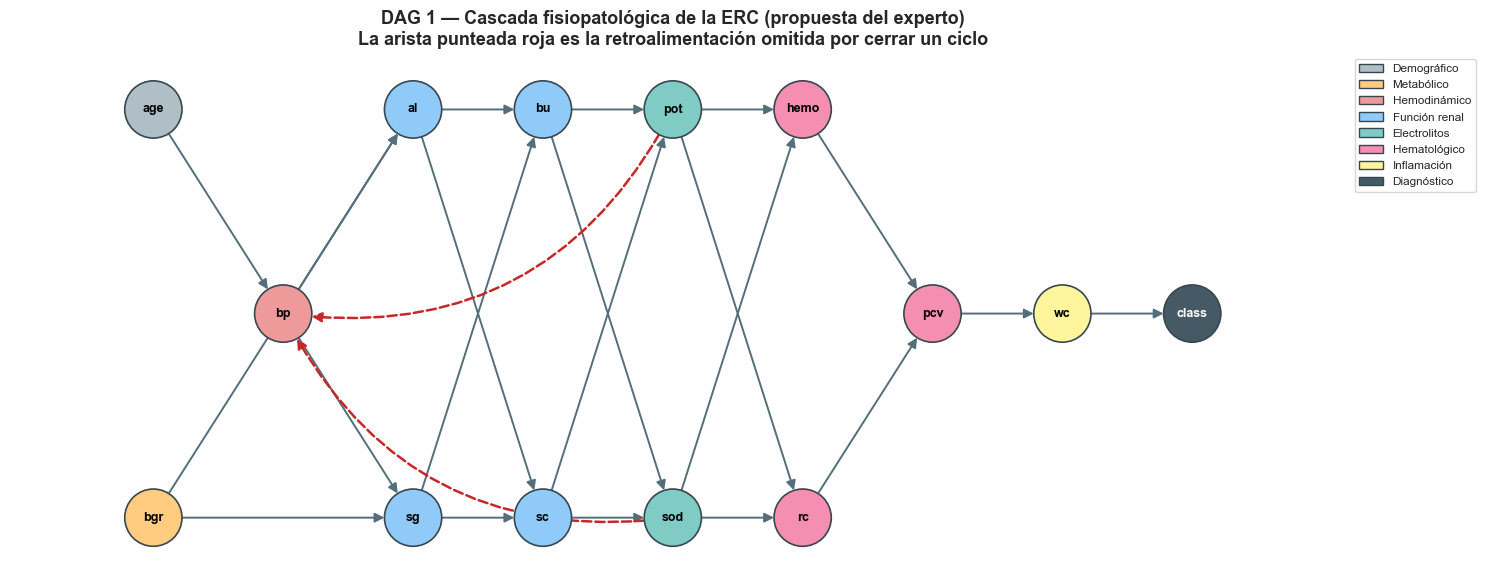

In [8]:
graficar_dag(DAG_1,
             'DAG 1 — Cascada fisiopatológica de la ERC (propuesta del experto)\n'
             'La arista punteada roja es la retroalimentación omitida por cerrar un ciclo',
             figsize=(15, 6), sep_x=2.0, sep_y=1.6,
             aristas_extra=RETROALIMENTACION)
plt.tight_layout()
plt.show()

**Observaciones de la DAG 1:**

- La estructura es una **cascada casi lineal**: 9 capas para 14 variables. Es la traducción directa de "una cosa lleva a la otra" del razonamiento clínico.

- `bgr` es la única variable que entra fuera de la cadena principal, reflejando que la nefropatía diabética tiene **una vía de daño independiente de la presión arterial**.

- `classification` queda como **hoja al final de la cascada**. Esto invierte la convención diagnóstica habitual (enfermedad → signo) y la sustituye por una lectura acumulativa: la ERC no es lo que causa los hallazgos, es la etiqueta que se asigna cuando toda la cascada ya ocurrió. Es una decisión defendible, pero tiene una consecuencia práctica: al usar la red para **predecir** el diagnóstico, toda la evidencia entra por un único padre (`wc`), lo que puede limitar el poder predictivo.

- La cadena `sod`;`pot` → `rc`;`hemo` **hereda la posición** que ocupaban esas variables en la cascada original: al omitir el retorno hacia `bp`, los electrolitos quedan como padres de la anemia. Clínicamente el vínculo real no es electrolito → anemia, sino que ambos comparten la misma causa (la caída del filtrado). Esta es la principal deuda estructural que deja la omisión del ciclo, y motiva las propuestas alternativas de las secciones siguientes.

## **4. DAG 2 — Modelo Fisiopatológico Ampliado (25 variables)**

La DAG 1 usa 14 de las 25 variables disponibles y coloca el diagnóstico como hoja final. Esta segunda propuesta explora la **convención diagnóstica clásica en medicina**: la enfermedad es la causa latente y los hallazgos de laboratorio son sus manifestaciones. Bajo esa lectura la flecha va `enfermedad → signo`, porque la creatinina sube *porque* el riñón falla.

Incorpora además las comorbilidades y los hallazgos urinarios que la DAG 1 no usa.

### Mecanismos representados

1. **Factores de riesgo basales.** `age` es la única raíz clínica: con la edad aumentan la probabilidad de hipertensión (`htn`), diabetes (`dm`) y enfermedad coronaria (`cad`), y cae el filtrado glomerular por sí sola.

2. **Las dos grandes causas de ERC.** `htn` y `dm` son, en ese orden, las etiologías más frecuentes de enfermedad renal crónica en la práctica clínica. Ambas apuntan a `classification`.

3. **Distinción diagnóstico / medición.** `htn` es el *diagnóstico previo* de hipertensión y `bp` la *presión medida en consulta*. Por eso `htn → bp` y no al revés. `bp` recibe también flecha de `classification`, porque el riñón enfermo retiene sodio y eleva la presión: así se captura la retroalimentación que en la DAG 1 tuvo que omitirse, sin generar ciclo.

4. **Manifestaciones renales.** La ERC produce simultáneamente proteinuria (`al`), pérdida de concentración urinaria (`sg`), retención de creatinina (`sc`), hematuria (`rbc`) y anemia (`hemo`).

5. **Cascada de la caída del filtrado.** `sc` es el marcador del filtrado perdido, y de él dependen la urea (`bu`) y los electrolitos (`sod`, `pot`). Esto corrige la deuda de la DAG 1: aquí los electrolitos y la anemia **no dependen uno del otro**, dependen de la causa que comparten.

6. **Anemia renal.** `hemo` gobierna `pcv` y `rc` porque las tres miden la misma masa eritrocitaria, y define la etiqueta clínica `ane`.

7. **Síndrome urémico y edema.** La urea alta y la anemia producen anorexia (`appet`); la pérdida de albúmina y la retención de sodio producen edema (`pe`).

8. **Vía infecciosa independiente.** `ba → pc`, `pcc` y de ahí la leucocitosis (`wc`), que recibe además el efecto inflamatorio de la propia ERC. Es un subgrafo que no pasa por el eje renal.

In [9]:
aristas_dag2 = [
    # 1. Factores de riesgo basales
    ('age', 'htn'), ('age', 'dm'), ('age', 'cad'), ('age', 'sc'), ('age', 'classification'),

    # 2. Hipertensión y diabetes: las dos causas principales de ERC
    ('htn', 'classification'), ('htn', 'bp'), ('htn', 'cad'),
    ('dm', 'classification'), ('dm', 'bgr'), ('dm', 'cad'),
    ('bgr', 'su'),                                   # glucosuria al rebasar el umbral renal

    # 3-4. La ERC como causa latente de sus manifestaciones
    ('classification', 'bp'),                        # retención de sodio → hipertensión secundaria
    ('classification', 'al'), ('classification', 'sg'), ('classification', 'sc'),
    ('classification', 'rbc'), ('classification', 'hemo'), ('classification', 'wc'),

    # 5. Caída del filtrado → acumulación de solutos
    ('sc', 'bu'), ('sc', 'sod'), ('sc', 'pot'),

    # 6. Anemia renal: hemo gobierna las otras dos mediciones de masa eritrocitaria
    ('hemo', 'pcv'), ('hemo', 'rc'), ('hemo', 'ane'),

    # 7. Síndrome urémico y edema
    ('bu', 'appet'), ('ane', 'appet'),
    ('al', 'pe'), ('sod', 'pe'),

    # 8. Vía infecciosa, independiente del eje renal
    ('ba', 'pc'), ('ba', 'pcc'), ('pc', 'wc'),
]

DAG_2 = construir_dag(aristas_dag2, nombre='DAG 2 (fisiopatológica ampliada)')

# Esta propuesta debe cubrir TODAS las variables del dataset crudo
print(f'Variables del crudo sin representar: '
      f'{set(crudo.columns) - set(DAG_2.nodes()) or "ninguna ✔"}')
print(f'Nodos de la DAG sin columna en el crudo: '
      f'{set(DAG_2.nodes()) - set(crudo.columns) or "ninguno ✔"}')

DAG 2 (fisiopatológica ampliada): 25 nodos, 32 aristas — acíclica ✔
Variables del crudo sin representar: ninguna ✔
Nodos de la DAG sin columna en el crudo: ninguno ✔


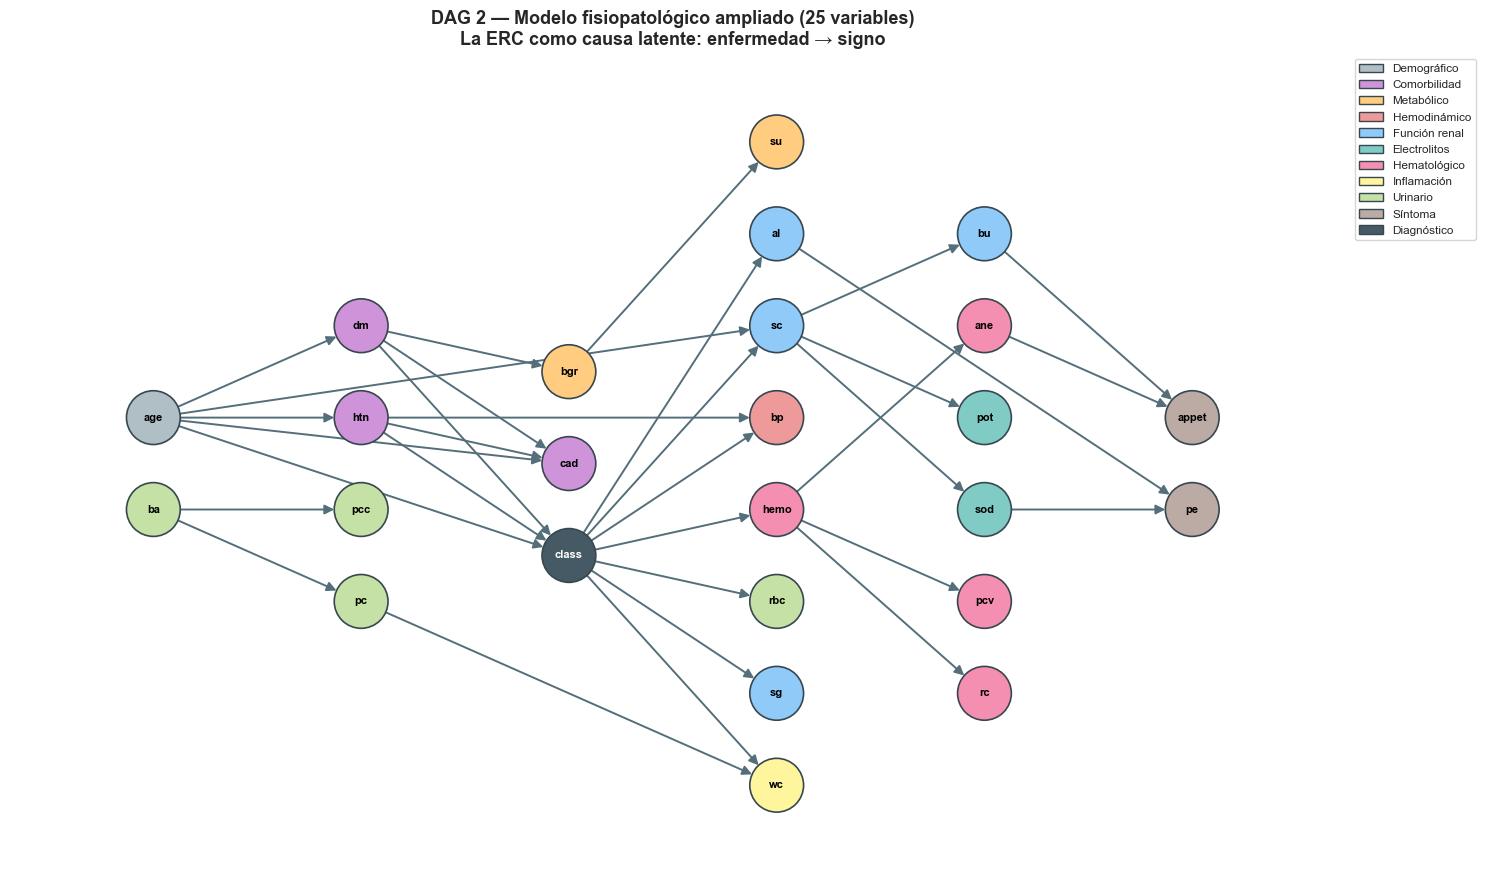

In [10]:
graficar_dag(DAG_2,
             'DAG 2 — Modelo fisiopatológico ampliado (25 variables)\n'
             'La ERC como causa latente: enfermedad → signo',
             figsize=(15, 9), sep_x=2.6, sep_y=1.35, tam_nodo=1500, fuente=8)
plt.tight_layout()
plt.show()

**Observaciones de la DAG 2:**

- Es **más ancha y menos profunda** que la DAG 1: en vez de una cadena de 9 eslabones, hay un nodo central (`classification`) del que se abren las manifestaciones en paralelo. Estructuralmente es una red *tipo naive-Bayes extendida*.

- Con `classification` como padre, cada hallazgo aporta evidencia **directa** al diagnóstico durante la inferencia, en lugar de tener que propagarse por ocho capas.

- El subgrafo infeccioso (`ba → pc`,`pcc` → `wc`) queda **casi desconectado** del eje renal. Es correcto: una infección urinaria puede existir sin ERC, y esa independencia es información útil para el modelo.

- Costo: al no ser todas las variables continuas, **esta DAG no puede ajustarse tal cual como Red Bayesiana Gaussiana**. Sirve como modelo conceptual de referencia y como fuente de restricciones para el aprendizaje estructural.

## **5. DAG 3 — Modelo Parsimonioso sobre el Eje Renal**

Tercera propuesta, construida bajo un criterio distinto: **incluir únicamente las aristas sobre las que existe consenso fisiológico fuerte**, y descartar toda relación discutible. Opera sobre las mismas 14 variables de la DAG 1, para que ambas sean directamente comparables.

El principio organizador es que **`sc` (creatinina) es el eje del modelo**, porque es el mejor marcador indirecto del filtrado glomerular. Casi todo lo demás que ocurre en la ERC es consecuencia de esa pérdida de filtrado:

- **Aguas arriba de `sc`** (lo que daña al riñón): la edad, la presión arterial y la glucemia, esta última y la presión actuando a través de la proteinuria (`al`), que además acelera por sí misma la progresión del daño.
- **Aguas abajo de `sc`** (consecuencias de la pérdida de filtrado): urea (`bu`), electrolitos (`sod`, `pot`), pérdida de concentración urinaria (`sg`), anemia (`hemo` → `pcv`, `rc`) e inflamación (`wc`).
- **El diagnóstico** recibe solo dos padres: `sc` y `al`, que son exactamente los **dos criterios con los que se define y estadifica la ERC** en la práctica clínica (filtrado glomerular y albuminuria).

Aristas deliberadamente **excluidas** por ser discutibles: `age → sg`, `age → bgr`, `bp → sc` directa (se prefiere la vía por `al`), y cualquier relación entre electrolitos y anemia.

In [11]:
aristas_dag3 = [
    # Aguas arriba: lo que daña al riñón
    ('age', 'bp'),                                   # rigidez arterial con la edad
    ('age', 'sc'),                                   # descenso fisiológico del filtrado
    ('bp', 'al'),                                    # daño glomerular hipertensivo → proteinuria
    ('bgr', 'al'),                                   # nefropatía diabética → proteinuria
    ('al', 'sc'),                                    # la proteinuria acelera la pérdida de filtrado

    # Aguas abajo: consecuencias de la caída del filtrado
    ('sc', 'sg'),                                    # isostenuria: se pierde la concentración urinaria
    ('sc', 'bu'), ('sc', 'sod'), ('sc', 'pot'),      # acumulación de solutos
    ('sc', 'hemo'),                                  # déficit de eritropoyetina
    ('sc', 'wc'),                                    # inflamación crónica urémica
    ('hemo', 'pcv'), ('hemo', 'rc'),                 # misma masa eritrocitaria

    # Diagnóstico: los dos criterios clínicos de la ERC
    ('sc', 'classification'), ('al', 'classification'),
]

DAG_3 = construir_dag(aristas_dag3, nombre='DAG 3 (parsimoniosa)')

DAG 3 (parsimoniosa): 14 nodos, 15 aristas — acíclica ✔


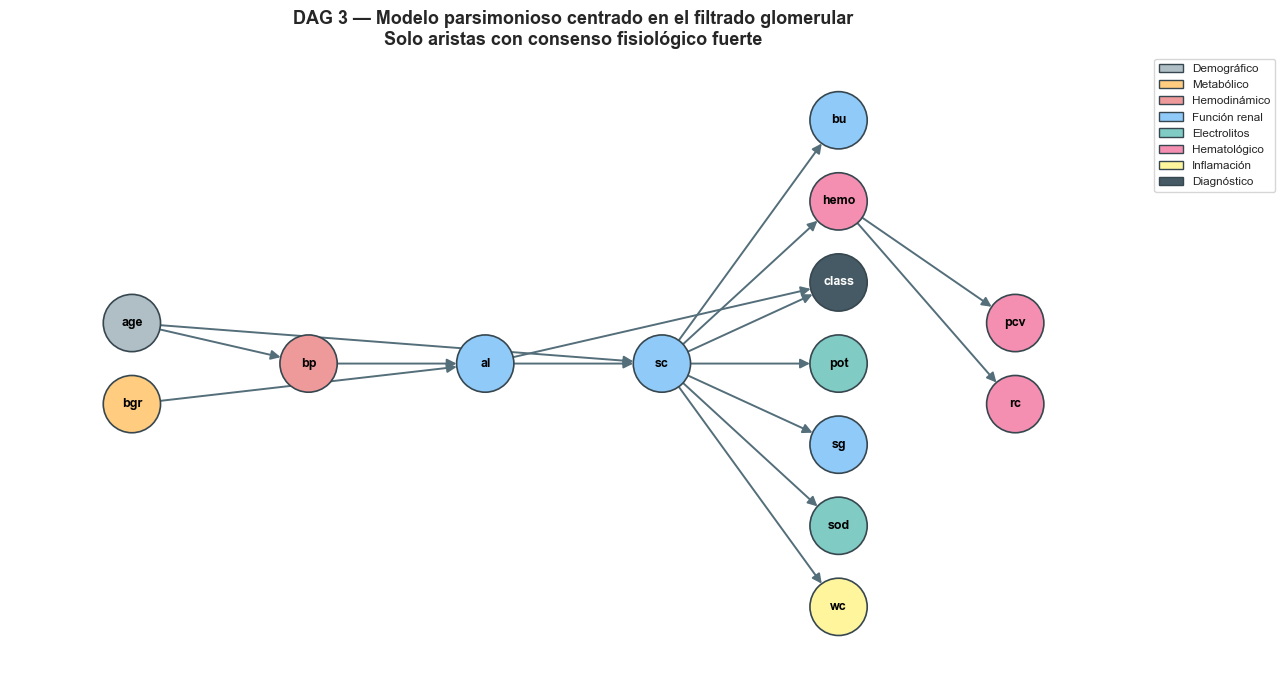

In [12]:
graficar_dag(DAG_3,
             'DAG 3 — Modelo parsimonioso centrado en el filtrado glomerular\n'
             'Solo aristas con consenso fisiológico fuerte',
             figsize=(13, 7), sep_x=2.2, sep_y=1.5)
plt.tight_layout()
plt.show()

**Observaciones de la DAG 3:**

- `sc` concentra **8 hijos**: es un cuello de botella deliberado. Toda la información sobre el estado renal pasa por un solo nodo, lo que hace la red fácil de interpretar y barata de estimar.

- Solo **4 capas** de profundidad frente a las 9 de la DAG 1: las consecuencias del daño renal se declaran **paralelas entre sí**, no secuenciales. Es la diferencia conceptual de fondo con la propuesta del experto.

- Al tener menos aristas es la estructura **menos propensa a sobreajuste** con 400 observaciones, pero también la que más riesgo tiene de omitir dependencias reales.

## **6. Comparación Estructural de las Tres Propuestas**

Las tres estructuras describen la misma enfermedad con arquitecturas distintas. Se comparan en tamaño, forma y costo de estimación.

In [13]:
comparacion = pd.DataFrame([
    resumen_dag(DAG_1, 'DAG 1 — cascada del experto'),
    resumen_dag(DAG_2, 'DAG 2 — ampliada (25 vars)'),
    resumen_dag(DAG_3, 'DAG 3 — parsimoniosa'),
]).set_index('DAG')

comparacion

,nodos,aristas,densidad,raíces,hojas,profundidad,grado_entrada_max,parámetros
DAG,,,,,,,,
DAG 1 — cascada del experto,14,21,0.231,2,1,9,2,49
DAG 2 — ampliada (25 vars),25,32,0.107,2,12,6,3,82
DAG 3 — parsimoniosa,14,15,0.165,2,8,6,2,43


In [14]:
# Con 400 observaciones, conviene ver cuántos datos hay por parámetro a estimar.
observaciones = len(crudo)
tabla = comparacion[['nodos', 'aristas', 'profundidad', 'parámetros']].copy()
tabla['obs_por_parámetro'] = (observaciones / tabla['parámetros']).round(1)

print(f'Observaciones disponibles: {observaciones}\n')
tabla

Observaciones disponibles: 400



,nodos,aristas,profundidad,parámetros,obs_por_parámetro
DAG,,,,,
DAG 1 — cascada del experto,14,21,9,49,8.2
DAG 2 — ampliada (25 vars),25,32,6,82,4.9
DAG 3 — parsimoniosa,14,15,6,43,9.3


### Aristas compartidas y exclusivas (DAG 1 vs DAG 3)

Ambas operan sobre las mismas 14 variables, así que la comparación arista por arista es directa. Se compara también el **esqueleto** (el grafo sin direcciones): dos expertos pueden coincidir en que dos variables se relacionan y discrepar en quién causa a quién.

In [15]:
E1, E3 = set(DAG_1.edges()), set(DAG_3.edges())
S1 = {frozenset(e) for e in E1}          # esqueleto: relación sin dirección
S3 = {frozenset(e) for e in E3}

# Relaciones presentes en ambas pero con la flecha al revés
invertidas = sorted(e for e in E1 if frozenset(e) in S3 and e not in E3)

print(f'Aristas DAG 1: {len(E1)}   |   Aristas DAG 3: {len(E3)}')
print(f'Idénticas (mismos nodos y dirección) : {len(E1 & E3):>2}  -> {sorted(E1 & E3)}')
print(f'Misma relación, dirección opuesta    : {len(invertidas):>2}  -> {invertidas}')
print(f'Coincidencias del esqueleto          : {len(S1 & S3):>2}')
print(f'\nExclusivas de la DAG 1 ({len(E1 - E3)}):')
for e in sorted(E1 - E3):
    print(f'    {e[0]:>5s} -> {e[1]}')
print(f'\nExclusivas de la DAG 3 ({len(E3 - E1)}):')
for e in sorted(E3 - E1):
    print(f'    {e[0]:>5s} -> {e[1]}')

Aristas DAG 1: 21   |   Aristas DAG 3: 15
Idénticas (mismos nodos y dirección) :  7  -> [('age', 'bp'), ('al', 'sc'), ('bgr', 'al'), ('bp', 'al'), ('hemo', 'pcv'), ('sc', 'pot'), ('sc', 'sod')]
Misma relación, dirección opuesta    :  1  -> [('sg', 'sc')]
Coincidencias del esqueleto          :  8

Exclusivas de la DAG 1 (14):
       al -> bu
      bgr -> sg
       bp -> sg
       bu -> pot
       bu -> sod
      pcv -> wc
      pot -> hemo
      pot -> rc
       rc -> pcv
       sg -> bu
       sg -> sc
      sod -> hemo
      sod -> rc
       wc -> classification

Exclusivas de la DAG 3 (8):
      age -> sc
       al -> classification
     hemo -> rc
       sc -> bu
       sc -> classification
       sc -> hemo
       sc -> sg
       sc -> wc


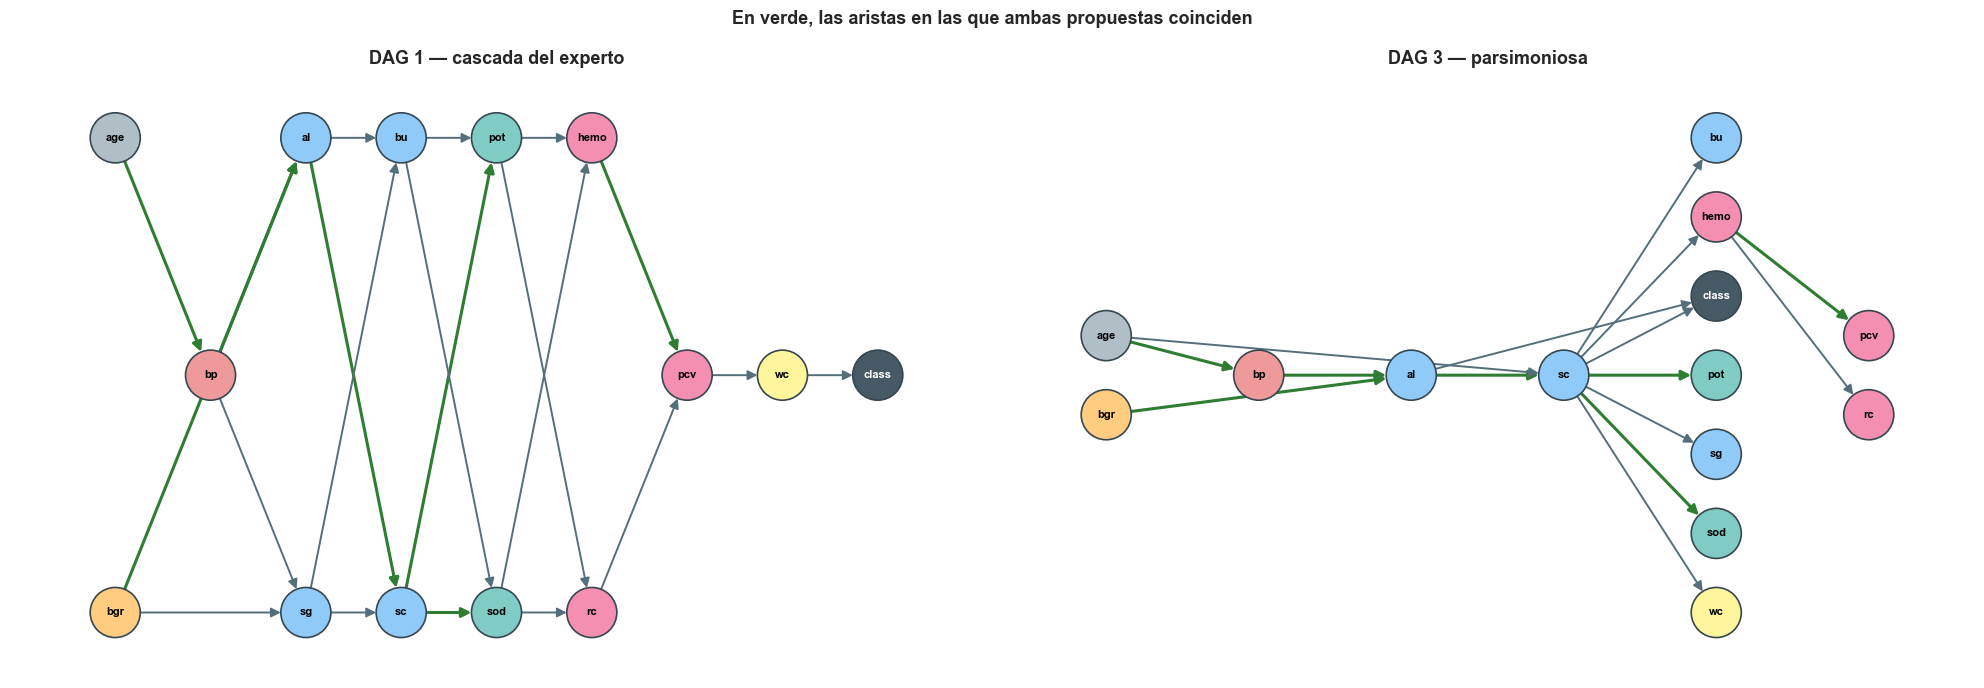

In [16]:
# Las aristas en las que ambos expertos coinciden se pintan en verde.
compartidas = E1 & E3
color_compartida = '#2e7d32'

fig, ejes = plt.subplots(1, 2, figsize=(20, 7))

graficar_dag(DAG_1, 'DAG 1 — cascada del experto', ax=ejes[0], leyenda=False,
             sep_x=2.0, sep_y=1.5, tam_nodo=1300, fuente=8,
             colores_aristas={e: color_compartida for e in compartidas})

graficar_dag(DAG_3, 'DAG 3 — parsimoniosa', ax=ejes[1], leyenda=False,
             sep_x=2.2, sep_y=1.5, tam_nodo=1300, fuente=8,
             colores_aristas={e: color_compartida for e in compartidas})

fig.suptitle('En verde, las aristas en las que ambas propuestas coinciden',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Consecuencias probabilísticas de elegir una u otra estructura

La estructura no es un dibujo: determina **qué variables se vuelven irrelevantes** una vez observadas otras. Dos herramientas lo muestran:

- El **manto de Markov** de una variable son los nodos que la vuelven independiente de todo lo demás. Al predecir el diagnóstico, solo ese conjunto aporta información.
- La **d-separación** dice si dos variables quedan desconectadas al condicionar sobre un tercer conjunto.

In [17]:
# pgmpy valida las estructuras como redes bayesianas y calcula independencias.
redes = {
    'DAG 1': DAG(list(DAG_1.edges())),
    'DAG 2': DAG(list(DAG_2.edges())),
    'DAG 3': DAG(list(DAG_3.edges())),
}

print('Manto de Markov de "classification" (lo único que importa para predecir el diagnóstico):\n')
for nombre, red in redes.items():
    manto = sorted(red.get_markov_blanket('classification'))
    print(f'  {nombre}: {len(manto)} variables -> {manto}')

Manto de Markov de "classification" (lo único que importa para predecir el diagnóstico):

  DAG 1: 1 variables -> ['wc']
  DAG 2: 11 variables -> ['age', 'al', 'bp', 'dm', 'hemo', 'htn', 'pc', 'rbc', 'sc', 'sg', 'wc']
  DAG 3: 2 variables -> ['al', 'sc']


In [18]:
# ¿Sigue importando la presión arterial una vez conocida la creatinina?
#   Es la pregunta que separa a las tres propuestas.
preguntas = [
    ('bp', 'classification', ['sc']),
    ('age', 'hemo', ['sc']),
    ('bgr', 'bu', ['sc']),
    ('hemo', 'pot', ['sc']),
]

filas = []
for x, y, z in preguntas:
    fila = {'X': x, 'Y': y, 'condicionado a': ', '.join(z)}
    for nombre, red in redes.items():
        conectados = red.is_dconnected(x, y, observed=z)
        fila[nombre] = 'dependientes' if conectados else 'independientes'
    filas.append(fila)

pd.DataFrame(filas).set_index(['X', 'Y', 'condicionado a'])

,,,DAG 1,DAG 2,DAG 3
X,Y,condicionado a,,,
bp,classification,sc,dependientes,dependientes,dependientes
age,hemo,sc,dependientes,dependientes,independientes
bgr,bu,sc,dependientes,independientes,independientes
hemo,pot,sc,dependientes,independientes,independientes


**Observaciones de la comparación:**

- Las dos propuestas coinciden en **7 aristas idénticas** y discrepan en la dirección de una sola: `sg` ↔ `sc`. El experto la orienta `sg → sc` (la pérdida de concentración urinaria precede a la retención de creatinina); la DAG 3 la orienta `sc → sg` (ambas son consecuencia de la caída del filtrado, y la creatinina es el marcador más temprano y confiable). Es la discrepancia más concreta y la más fácil de llevar de vuelta al experto.

- El manto de Markov de `classification` es la diferencia más práctica entre las propuestas. En la **DAG 1** el diagnóstico depende de un vecindario mínimo, porque cuelga al final de la cascada; en la **DAG 2** y la **DAG 3** recibe evidencia de varios marcadores a la vez.

- `hemo` y `pot`: la **DAG 1** las declara dependientes incluso conociendo `sc` (por la cadena `sod`;`pot` → `hemo`), mientras que la **DAG 3** las vuelve independientes al condicionar sobre la creatinina. Esta es exactamente la deuda estructural que dejó la omisión del ciclo, y es una **hipótesis contrastable con los datos**.

- La DAG 3 es la más barata de estimar en observaciones por parámetro; la DAG 1 es la más fiel al razonamiento clínico dictado; la DAG 2 es la única que cubre las 25 variables pero no es ajustable como red gaussiana.

## **7. Exportación de las Estructuras**

Las tres DAGs se guardan en un único JSON para que el notebook de modelado las cargue sin volver a declararlas.

In [19]:
estructuras = {
    'dag_1_experto': {
        'nombre': 'Cascada fisiopatológica del experto',
        'descripcion': 'Cadena secuencial dictada por el experto clínico. Omite la '
                       'retroalimentación sod/pot -> bp por cerrar un ciclo.',
        'variables': sorted(DAG_1.nodes()),
        'aristas': sorted(DAG_1.edges()),
        'aristas_omitidas_por_ciclo': sorted(RETROALIMENTACION),
        'apta_red_gaussiana': True,
    },
    'dag_2_ampliada': {
        'nombre': 'Modelo fisiopatológico ampliado',
        'descripcion': 'Convención diagnóstica clásica (enfermedad -> signo) sobre las '
                       '25 variables, incluidas comorbilidades y hallazgos urinarios.',
        'variables': sorted(DAG_2.nodes()),
        'aristas': sorted(DAG_2.edges()),
        'aristas_omitidas_por_ciclo': [],
        'apta_red_gaussiana': False,
    },
    'dag_3_parsimoniosa': {
        'nombre': 'Modelo parsimonioso sobre el eje renal',
        'descripcion': 'Solo aristas con consenso fisiológico fuerte, centradas en la '
                       'creatinina como marcador del filtrado glomerular.',
        'variables': sorted(DAG_3.nodes()),
        'aristas': sorted(DAG_3.edges()),
        'aristas_omitidas_por_ciclo': [],
        'apta_red_gaussiana': True,
    },
}

destino = RAIZ / 'data' / 'dags' / 'dags_expertos.json'
destino.parent.mkdir(parents=True, exist_ok=True)

with open(destino, 'w', encoding='utf-8') as f:
    json.dump(estructuras, f, indent=2, ensure_ascii=False)

print(f'Guardado en: {destino.relative_to(RAIZ)}')
for clave, e in estructuras.items():
    print(f'  {clave:22s} {len(e["variables"]):>2} variables, {len(e["aristas"]):>2} aristas')

Guardado en: data/dags/dags_expertos.json
  dag_1_experto          14 variables, 21 aristas
  dag_2_ampliada         25 variables, 32 aristas
  dag_3_parsimoniosa     14 variables, 15 aristas


In [20]:
# Reconstrucción desde el archivo: confirma que lo exportado se puede volver a usar.
with open(destino, encoding='utf-8') as f:
    recuperado = json.load(f)

for clave, e in recuperado.items():
    G = nx.DiGraph([tuple(a) for a in e['aristas']])
    G.add_nodes_from(e['variables'])
    assert nx.is_directed_acyclic_graph(G), f'{clave} dejó de ser acíclica'
    print(f'{clave:22s} reconstruida ✔  ({G.number_of_nodes()} nodos, {G.number_of_edges()} aristas)')

dag_1_experto          reconstruida ✔  (14 nodos, 21 aristas)
dag_2_ampliada         reconstruida ✔  (25 nodos, 32 aristas)
dag_3_parsimoniosa     reconstruida ✔  (14 nodos, 15 aristas)


## **8. Resumen**

**Estructuras propuestas**

| DAG | Origen | Variables | Idea central | Uso previsto |
|---|---|---|---|---|
| **1** | Dictada por el experto clínico | 14 | La ERC es una **cascada secuencial**: cada etapa del daño produce la siguiente | Estructura fija para la Red Bayesiana Gaussiana |
| **2** | Fisiopatología clásica de la ERC | 25 | La ERC es una **causa latente** cuyos signos se manifiestan en paralelo | Modelo conceptual y fuente de restricciones |
| **3** | Criterio de consenso mínimo | 14 | El **filtrado glomerular (`sc`) es el eje**; todo lo demás cuelga de él | Referencia parsimoniosa para comparar |

**Decisiones de modelado documentadas**

1. **Ciclo roto en la DAG 1.** El experto describió que la acumulación de electrolitos vuelve a elevar la presión arterial. Se omitieron las aristas `sod → bp` y `pot → bp`; se conservan registradas en el JSON exportado y dibujadas en rojo. La DAG 2 recupera ese mecanismo sin ciclo, por la vía `classification → bp`.

2. **`bgr` incorporado por vía independiente.** La glucemia entra directamente sobre `al` y `sg`, no a través de `bp`: la nefropatía diabética daña el glomérulo por un mecanismo propio.

3. **Dirección de `classification`.** La DAG 1 la trata como hoja (etiqueta acumulada); la DAG 2 y la 3 le dan padres clínicos. Es la discrepancia estructural de fondo entre las propuestas y conviene resolverla con el experto antes del ajuste final.

**Siguientes pasos**

1. Ajustar la Red Bayesiana Gaussiana con la DAG 1 y con la DAG 3 sobre `ckd_imputado.csv`.
2. Comparar ambos ajustes por verosimilitud penalizada (BIC) y validación cruzada.
3. Contrastar las estructuras de expertos contra la que aprenda un algoritmo de búsqueda estructural, usando el JSON exportado como conjunto de restricciones.

**Dudas al profesor:**

1. ¿`classification` debe ir como hoja al final de la cascada (DAG 1) o como causa latente de los hallazgos (DAG 2 y 3)? Cambia por completo el manto de Markov del diagnóstico.

2. Al romper el ciclo `sod`;`pot → bp`, ¿es preferible omitir la arista, o desdoblar `bp` en dos nodos temporales aunque el dataset tenga una sola columna?

3. ¿Se ajusta la red sobre todos los registros o solo sobre los pacientes con `classification = ckd`?